In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
from torch.nn import BCEWithLogitsLoss

import monk_common as mc
import nn_common as nnc
import cross_common as cr
import torch
from torch import nn
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MSE,FOLD_VL_MSE,FOLD_TR_MSE
from cross_common import MEE,MSE,RMSE,MAE,ACC
from cross_common import (FOLD_VL_CUSTOM, FOLD_TR_CUSTOM)


importlib.reload(nnc)
importlib.reload(mc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
df_train, df_test = mc.load_set(1)
# Scaler
scaler = StandardScaler()
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
from torch import nn

# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 1

# fold strategy
base_fold_strategy = cr.common_fold_strategy(stratified=True, n_split=3)

default_batch_size = 20

# ----- Defining model basic architecture --------
base_hidden_layers = ["4"]

# The output and loss function, must be changed according to the type of task
loss_function = BCEWithLogitsLoss() #nn.MSELoss
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.binary_bce_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-3 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta, metric="custom")
# ------------------------------------------


# -- The metrics to compute during training -
epochs_metrics_dict = {
    MSE: (cr.mse,min),
    "custom": (loss_function,max)
}
# -------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = trial_dict["batch_size"]
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_mlp(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.MLP(net_trial, output_adapter_trial)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "metrics": metrics_trial,
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    mc.evaluate_lr,
    epoch_metric="epochs_tr_custom",
    fold_metric="fold_vl_custom",
    early_epoch=30
)

#coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]
coarse_learning_rates = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2]

<h5>Coarse Grained</h5>

In [7]:
importlib.reload(nnc)
importlib.reload(mc)
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

default_epochs = 500
objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-03-27 06:30:57,877] A new study created in memory with name: no-name-0a4707c7-aefe-496f-b04a-9f8782f51a1e
  5%|▌         | 1/20 [00:02<00:42,  2.26s/it]

[I 2026-03-27 06:31:00,144] Trial 0 finished with values: [0.70056512295346, 0.0024308438646783804] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.005, 'weight_decay': 0}.


 10%|█         | 2/20 [00:05<00:50,  2.83s/it]

[I 2026-03-27 06:31:03,378] Trial 1 finished with values: [0.7945977551758036, 0.0012513426026295666] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:07<00:44,  2.59s/it]

...

[I 2026-03-27 06:31:50,089] Trial 17 finished with values: [0.8579050558877, 0.005488139147934878] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.005, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:55<00:02,  2.88s/it]

[I 2026-03-27 06:31:53,341] Trial 18 finished with values: [0.7209767284628222, 0.0005937748188886731] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


100%|██████████| 20/20 [00:58<00:00,  2.93s/it]

[I 2026-03-27 06:31:56,390] Trial 19 finished with values: [0.7693900957305533, 0.004677262125781934] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.01, 'weight_decay': 0}.


In [8]:
importlib.reload(mc)
coarse_grained_lr = mc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.005


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-03-27 06:31:56,453] A new study created in memory with name: no-name-543477f0-fe9c-45ad-a579-e103138facc3
  3%|▎         | 1/30 [00:01<00:37,  1.28s/it]

[I 2026-03-27 06:31:57,736] Trial 0 finished with values: [0.7265586502571705, 0.005368246937339227] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.01002124911685945, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:04<01:07,  2.40s/it]

[I 2026-03-27 06:32:00,912] Trial 1 finished with values: [0.6972863640530923, 0.001198469541404983] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002633117924766537, 'weight_decay': 0}.


 10%|█         | 3/30 [00:05<00:48,  1.79s/it]

...

[I 2026-03-27 06:33:05,250] Trial 27 finished with values: [0.7945181712150527, 0.005308471373331169] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.011170382728141968, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [01:10<00:02,  2.44s/it]

[I 2026-03-27 06:33:07,142] Trial 28 finished with values: [0.6988872992487042, 0.004808760695912557] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.010252285539085993, 'weight_decay': 0}.


100%|██████████| 30/30 [01:13<00:00,  2.44s/it]

[I 2026-03-27 06:33:09,564] Trial 29 finished with values: [0.8732682411125174, 0.005837216264474823] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.004059863573692481, 'weight_decay': 0}.


In [10]:
final_lr = mc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.005 0.002019256702312771


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [11]:

evaluate_wd_partial = partial(
    nnc.evaluate_wd,
    vl_key=FOLD_VL_CUSTOM,
    tr_key=FOLD_TR_CUSTOM,
)

#coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]
coarse_weight_decays = [0.0, 1e-6, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [12]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-03-27 06:33:09,742] A new study created in memory with name: no-name-3d423514-0824-4d44-b7f7-9fc655e61808
  5%|▌         | 1/20 [00:03<01:00,  3.17s/it]

[I 2026-03-27 06:33:12,909] Trial 0 finished with values: [0.7938732596916882, 0.0008476483085059217] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0001}.


 10%|█         | 2/20 [00:07<01:09,  3.85s/it]

[I 2026-03-27 06:33:17,242] Trial 1 finished with values: [0.820143215609206, 0.001597548361687906] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 1e-06}.


 15%|█▌        | 3/20 [00:09<00:52,  3.09s/it]

...

[I 2026-03-27 06:34:07,966] Trial 17 finished with values: [0.7948034205064726, 0.002179926484982442] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0}.


 95%|█████████▌| 19/20 [01:02<00:03,  3.79s/it]

[I 2026-03-27 06:34:12,690] Trial 18 finished with values: [0.7708909877085933, 0.0024360145289175072] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 1e-05}.


100%|██████████| 20/20 [01:05<00:00,  3.27s/it]

[I 2026-03-27 06:34:15,202] Trial 19 finished with values: [0.7610844883446171, 0.002211853038936007] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0005}.


In [13]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0005


<h5>Fine Grained</h5>

In [14]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-03-27 06:34:15,327] A new study created in memory with name: no-name-1c24aa5d-aa8e-429f-a7ba-2d826055a8af
  3%|▎         | 1/30 [00:03<01:33,  3.23s/it]

[I 2026-03-27 06:34:18,561] Trial 0 finished with values: [0.6717685659611083, 0.004119679342135973] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00027428783068600426}.


  7%|▋         | 2/30 [00:05<01:21,  2.90s/it]

[I 2026-03-27 06:34:21,225] Trial 1 finished with values: [0.8121301110428615, 0.002329269122210764] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0001894721659534715}.


 10%|█         | 3/30 [00:09<01:29,  3.33s/it]

...

[I 2026-03-27 06:35:43,777] Trial 27 finished with values: [0.7405950600354191, 0.0019672297700312757] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0002073702555494868}.


 97%|█████████▋| 29/30 [01:31<00:03,  3.08s/it]

[I 2026-03-27 06:35:47,037] Trial 28 finished with values: [0.8149510244966892, 0.0033976350292186375] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0003576158346476937}.


100%|██████████| 30/30 [01:35<00:00,  3.20s/it]

[I 2026-03-27 06:35:51,206] Trial 29 finished with values: [0.6510732247531298, 0.0031116183200041725] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.0004842800029475498}.


In [15]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0005 Fine grained WD: 0.00020687567895009845


<h4>Model Capacity</h4>
<hr/>

In [16]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_CUSTOM,
    vl_key=FOLD_VL_CUSTOM
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": cr.common_fold_strategy(stratified=True, n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": ["4","8","16","24","32","8,16","16,24","24,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)


[I 2026-03-27 06:35:58,149] A new study created in memory with name: no-name-8a401f71-cfa9-4d11-a4ec-45de29cd3bb1
  3%|▎         | 1/30 [00:05<02:41,  5.58s/it]

[I 2026-03-27 06:36:03,726] Trial 0 finished with values: [0.7577675401543578, 0.060705488617296854] and parameters: {'hidden_layers': '16,24', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00020687567895009845}.


  7%|▋         | 2/30 [00:12<02:51,  6.12s/it]

[I 2026-03-27 06:36:10,229] Trial 1 finished with values: [0.7307031404972075, 0.019667629244351392] and parameters: {'hidden_layers': '24,32', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00020687567895009845}.


 10%|█         | 3/30 [00:19<02:57,  6.58s/it]

...

[I 2026-03-27 06:39:05,415] Trial 27 finished with values: [0.7101501456896465, 0.005207673780845967] and parameters: {'hidden_layers': '24', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00020687567895009845}.


 97%|█████████▋| 29/30 [03:14<00:06,  6.80s/it]

[I 2026-03-27 06:39:12,362] Trial 28 finished with values: [0.7244048273563385, 0.011185593641165559] and parameters: {'hidden_layers': '16,24', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00020687567895009845}.


100%|██████████| 30/30 [03:21<00:00,  6.71s/it]

[I 2026-03-27 06:39:19,464] Trial 29 finished with values: [0.8156478969256084, 0.005957171411225426] and parameters: {'hidden_layers': '16', 'activation': 'relu', 'learning_rate': 0.002019256702312771, 'weight_decay': 0.00020687567895009845}.


In [17]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [16] - best metrics: 0.6640196573734284 - best VL/TR gap: 0.005975187125832115


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [18]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [19]:
importlib.reload(nnc)
importlib.reload(mc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy(stratified=True, n_split=5)
net = nnc.build_mlp(input_dimension, output_dimension, final_hidden_layers, "relu")
model_template = nnc.MLP(net, nnc.binary_bce_adapter())

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=default_epochs
kv_batch_size=default_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "metrics": epochs_metrics_dict
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params
)

  
Perform fold: 0, train size: 99, val size: 25
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 99
Validation      | samples: 25
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.002019256702312771, 'weight_decay': 0.00020687567895009845, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | metric: custom,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 99, val size: 25
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 99
Validation      | samples: 25
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Opt

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

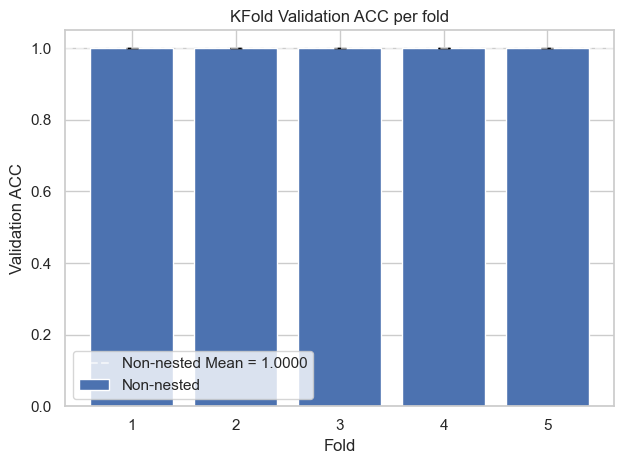

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,1.0,1.0,0.0,0.00%
2,1.0,1.0,0.0,0.00%
3,1.0,1.0,0.0,0.00%
4,1.0,1.0,0.0,0.00%
5,1.0,1.0,0.0,0.00%
MEAN,1.0,1.0,0.0,0.00%
STD,0.0,0.0,0.0,0.00%


In [20]:
importlib.reload(cr)
for metric in ["acc"]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [21]:
importlib.reload(cr)
importlib.reload(nnc)

def metrics_fn(y_pred, y_true)->dict:

    metrics = {
        MSE: cr.mse(y_true, y_pred),
        MAE: cr.mae(y_true, y_pred),
        #"acc": cr.accuracy(y_pred, y_true),
        "custom": nnc.compute_bce_from_numpy(y_true, y_pred)
    }
    return metrics

bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
#bootstrap_inner_train = copy.deepcopy(inner_train_params)
#bootstrap_inner_train.pop("split_strategy") # removed
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
#bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, metrics_fn, bootstrap_params)

In [22]:
importlib.reload(cr)
#cr.aggregate_scores(bootstrap_scores)
cr.aggregate_metrics(bootstrap_scores)

,metric,means,stds
0,custom,1.06,1.33
1,mae,5.25,0.90
2,mse,36.75,9.27


In [23]:
#cr.plot_bootstrap_distribution(["mee" for metric in bootstrap_scores])

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [24]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.2), # 0.1 = 10% - 0.2 = 20%
    **inner_train_params
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 100
Validation      | samples: 24
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.002019256702312771, 'weight_decay': 0.00020687567895009845, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | metric: custom,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------


In [26]:
epochs_kf_tr_custom = train_kf_result.epochs_tr_custom
epochs_kf_vl_custom = train_kf_result.epochs_vl_custom
epochs_kf_vl_acc = train_kf_result.epochs_vl_acc
epochs_kf_tr_acc = train_kf_result.epochs_tr_acc
epochs_kf_grad = train_kf_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

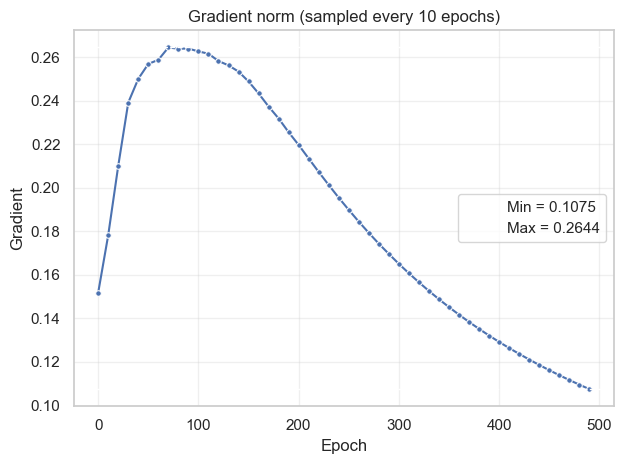

In [27]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

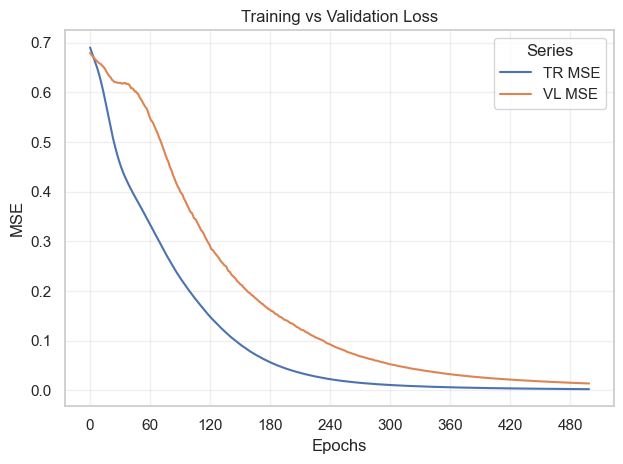

In [28]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_custom, epochs_kf_vl_custom)

In [30]:
importlib.reload(cr)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_custom)
print(f"{mean:.4f} ± {std:.4f}")

0.1851 ± 0.2057


<Figure size 640x480 with 0 Axes>

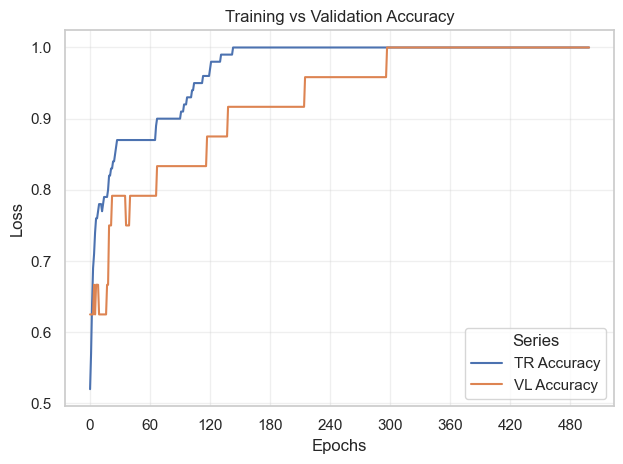

In [31]:
nnc.plot_epoch_accuracy(epochs_kf_tr_acc, epochs_kf_vl_acc)

In [32]:
from sklearn.metrics import classification_report

importlib.reload(nnc)
importlib.reload(mc)
y_pred = mc.classification_helper(model_final.predict(X_ts))
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       216

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432



<h3>Best Hyperparameters</h3>
<hr/>

In [33]:
#print(inner_train_params)
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

print(f"hidden layers: {final_hidden_layers}")

epochs: 500
batch_size: 20
scheduler_template: None
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.002019256702312771, weight_decay=0.00020687567895009845, betas=(0.95, 0.999))
loss_function: BCEWithLogitsLoss()
early_stopping_strategy: EarlyStopping monitoring custom with patience=50, min_delta=0.001
metrics: {'mse': (<function mse at 0x1217c1e80>, <built-in function min>), 'custom': (BCEWithLogitsLoss(), <built-in function max>)}
hidden layers: [16]
